In [1]:
import os
import numpy as np
import pandas as pd
import uproot
import PIL

import matplotlib.pyplot as plt

In [2]:
import keras
from keras import ops
from keras import layers
os.environ["KERAS_BACKEND"] = "tensorflow"

In [3]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [4]:
##importing libraries##
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

import time

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


In [5]:

ROOT_FILE = "/Users/ruthhodgson/geant4_apps/QEPET/build/out.root"

file = uproot.open(ROOT_FILE)

print(file.keys())
tree = file['ThreeG_NCS']

#use this for loop to check that all branches have the same keys

# for key in file.keys():
#     print(file[key].keys())
print(tree.keys())

branches  = [
    'EventID',
    'NGammas', 

    'AnnihilX_mm',  #these are the targets
    'AnnihilY_mm', 
    'AnnihilZ_mm', 
    
    'GammaIndex', 
    'GammaTrackID', 
    'GammaParentID', 
    
    'HitIndex', 
    
    'VolumeID', 
    'VolumeName', 
    'ProcessID', 
    'ProcessName', 
    
    'EnergyDeposit_keV',  #energies of the gamma photon at each detection point
    'PreEnergy_keV', 
    'PostEnergy_keV', 
    
    'X_mm',  #detection points
    'Y_mm', 
    'Z_mm', 
    'Theta_deg',
    'Phi_deg', 
    'DeltaPhi01_deg', 
    'DeltaPhi02_deg', 
    'DeltaPhi12_deg']

tree = file["ThreeG_NCS"]
df = tree.arrays(branches, library="pd")


['TwoG_NCS;1', 'TwoG_PhantomSCS;1', 'TwoG_ScannerSCS;1', 'TwoG_PhantomSCS_ScannerSCS;1', 'TwoG_PhantomDCS;1', 'TwoG_ScannerDCS;1', 'TwoG_PhantomSCS_ScannerDCS;1', 'TwoG_PhantomDCS_ScannerSCS;1', 'TwoG_PhantomDCS_ScannerDCS;1', 'TwoG_MCS;1', 'TwoG_Excluded;1', 'ThreeG_NCS;1', 'ThreeG_ScannerSCS;1', 'ThreeG_ScannerDCS;1', 'ThreeG_ScannerTCS;1', 'ThreeG_MCS;1', 'ThreeG_Excluded;1', 'Run;1']
['EventID', 'NGammas', 'AnnihilX_mm', 'AnnihilY_mm', 'AnnihilZ_mm', 'GammaIndex', 'GammaTrackID', 'GammaParentID', 'HitIndex', 'VolumeID', 'VolumeName', 'ProcessID', 'ProcessName', 'EnergyDeposit_keV', 'PreEnergy_keV', 'PostEnergy_keV', 'X_mm', 'Y_mm', 'Z_mm', 'Theta_deg', 'Phi_deg', 'DeltaPhi01_deg', 'DeltaPhi02_deg', 'DeltaPhi12_deg']


In [6]:
#num of detector hits = number of events / 3

print()

print("Number of detector hits =", len(df))

print()

# num = file['Run'].arrays('NumberOfEvents') 
print("Number of events =",
      df['EventID'].drop_duplicates().shape[0])

print()

print(df.describe())


Number of detector hits = 14172

Number of events = 4724

            EventID  NGammas   AnnihilX_mm   AnnihilY_mm   AnnihilZ_mm  \
count  14172.000000  14172.0  14172.000000  14172.000000  14172.000000   
mean   49877.296994      3.0      1.876523      2.944788     -8.170338   
std    29037.733845      0.0      1.985492      2.564852      1.875388   
min        2.000000      3.0     -3.133895     -2.247797    -13.033757   
25%    24946.500000      3.0      0.319652      0.746678     -9.544018   
50%    49979.500000      3.0      1.898903      2.946253     -8.172962   
75%    75152.250000      3.0      3.433019      5.161663     -6.803274   
max    99856.000000      3.0      6.600159      8.146037     -3.156985   

         GammaIndex  GammaTrackID  GammaParentID  HitIndex  VolumeID  ...  \
count  14172.000000  14172.000000        14172.0   14172.0   14172.0  ...   
mean       1.000000      3.000000            1.0       0.0       1.0  ...   
std        0.816525      0.816525          

In [7]:
IMG_SIZE = 64

xmin = df.X_mm.min()
xmax = df.X_mm.max()

ymin = df.Y_mm.min()
ymax = df.Y_mm.max()

zmin = df.Z_mm.min()
zmax = df.Z_mm.max()

print(xmin, xmax)
print(ymin, ymax)
print(zmin, zmax)

grouped_df = df.groupby(["EventID"])


images = []
targets = []

event_groups = df.groupby("EventID", sort=False)

# print(event_groups.head())

print(f"Building images from {event_groups.ngroups} events...")


for i, (event_id, event) in enumerate(event_groups):


    # all hits with this EventID belong to one event

    image = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)


    # Channel 0: XY projection

    H_xy, _, _ = np.histogram2d(
        event["X_mm"],
        event["Y_mm"],
        bins=IMG_SIZE,
        range=[[xmin, xmax], [ymin, ymax]],
        weights=event["EnergyDeposit_keV"]
    )
    
    image[:, :, 0] = H_xy



    # Channel 1: XZ projection

    H_xz, _, _ = np.histogram2d(
        event["X_mm"],
        event["Z_mm"],
        bins=IMG_SIZE,
        range=[[xmin, xmax], [zmin, zmax]],
        weights=event["EnergyDeposit_keV"]
    )

    image[:, :, 1] = H_xz



    # Channel 2: YZ projection

    H_yz, _, _ = np.histogram2d(
        event["Y_mm"],
        event["Z_mm"],
        bins=IMG_SIZE,
        range=[[ymin, ymax], [zmin, zmax]],
        weights=event["EnergyDeposit_keV"]
    )

    image[:, :, 2] = H_yz

    # Regression Targets


    annihil_x = event["AnnihilX_mm"].iloc[0]
    annihil_y = event["AnnihilY_mm"].iloc[0]
    annihil_z = event["AnnihilZ_mm"].iloc[0]

    target = [
        annihil_x,
        annihil_y,
        annihil_z,
    ]



    # Store image and target


    images.append(image)
    targets.append(target)


    if (i + 1) % 1000 == 0:
        print(f"{i+1} events processed")


# Convert lists to arrays
images = np.array(images, dtype=np.float16)
targets = np.array(targets, dtype=np.float32)


print("Images shape :", images.shape)
print("Targets shape:", targets.shape)

-93.85215 96.86018
-98.20408 93.24706
-94.92272 91.91468
Building images from 4724 events...
1000 events processed
2000 events processed
3000 events processed
4000 events processed
Images shape : (4724, 64, 64, 3)
Targets shape: (4724, 3)


In [8]:
print("Images:", images.shape)
print("Targets:", targets.shape)

print("\nExample target:")
print(targets[0])

images /= np.max(images)

Images: (4724, 64, 64, 3)
Targets: (4724, 3)

Example target:
[-0.29390496  4.0538282  -8.090448  ]


In [9]:
from sklearn.model_selection import train_test_split

batch_size = 8

X_train, X_test, y_train, y_test = train_test_split(
    images,
    targets,
    test_size=0.2,
    random_state=42
)

train_dataset = (
    tf.data.Dataset.from_tensor_slices(X_train)
    .shuffle(len(X_train))
    .batch(batch_size)
)

test_dataset = (
    tf.data.Dataset.from_tensor_slices(X_test)
    .batch(batch_size)
)

print("X Training images:", X_train.shape)
print("X Testing images:", X_test.shape)

print("Y Training targets:", y_train.shape)
print("Y Testing targets:", y_test.shape)

X Training images: (3779, 64, 64, 3)
X Testing images: (945, 64, 64, 3)
Y Training targets: (3779, 3)
Y Testing targets: (945, 3)


In [10]:
from sklearn.preprocessing import StandardScaler


target_scaler = StandardScaler()


y_train_scaled = target_scaler.fit_transform(y_train)

y_test_scaled = target_scaler.transform(y_test)

print(y_train_scaled[0])

[ 1.5224975  -1.2996156  -0.78591067]


In [53]:
print(y_train_scaled.shape, X_train.shape)

(3779, 3) (3779, 64, 64, 3)


**Create a Sampling Layer**

In [11]:
class Sampling(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.seed_generator = keras.random.SeedGenerator(event_groups.ngroups)
    
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = ops.shape(z_mean)[0]
        dim = ops.shape(z_mean)[1]
        epsilon = keras.random.normal(shape=(batch, dim), seed = self.seed_generator)
        return z_mean + ops.exp(0.5*z_log_var)*epsilon


        

**Encoder**

In [12]:
latent_dim = 32

encode_inputs = keras.Input(shape=(64, 64, 3))
x = layers.Conv2D(32, 3, activation = 'relu', strides = 2, padding= 'same')(encode_inputs)
x = layers.Conv2D(64, 3, activation = 'relu', strides = 2, padding= 'same')(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation = 'relu')(x)
z_mean = layers.Dense(latent_dim, name = "z_mean")(x)
z_log_var = layers.Dense(latent_dim, name = "z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder = keras.Model(encode_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()



Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 16, 16,    │     18,496 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 16384)     │          0 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │    262,160 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 32)        │        544 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 32)        │        544 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 32)        │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 282,640 (1.08 MB)

 Trainable params: 282,640 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

**Decoder**

In [13]:
latent_inputs = keras.Input(shape=(latent_dim, ))
x=layers.Dense(16*16*64, activation='relu')(latent_inputs)
x = layers.Reshape((16,16,64))(x)
x = layers.Conv2DTranspose(64, 3, activation='relu', strides = 2, padding = 'same')(x)
x = layers.Conv2DTranspose(32, 3, activation='relu', strides = 2, padding = 'same')(x)
decode_outputs = layers.Conv2DTranspose(3, 3, activation='sigmoid', padding = 'same')(x)
decoder = keras.Model(latent_inputs, decode_outputs, name = 'decoder')
decoder.summary()


Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16384)          │       540,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 32, 32, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 64, 64, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 3)      │           867 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 596,931 (2.28 MB)

 Trainable params: 596,931 (2.28 MB)

 Non-trainable params: 0 (0.00 B)

**Defining the VAE**

In [14]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name = 'total_loss')
        self.recon_loss_tracker = keras.metrics.Mean(name = 'recon_loss')
        self.kl_loss_tracker = keras.metrics.Mean(name = "kl_loss")

    @property
    def metrics(self): 
        return [
            self.total_loss_tracker,
            self.recon_loss_tracker,
            self.kl_loss_tracker
        ]   
    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var,z = self.encoder(data)
            recon = self.decoder(z)
            recon_loss = ops.mean(
                ops.sum(
                    keras.losses.binary_crossentropy(data, recon), axis=(1,2))
                )
            
            kl_loss = -0.5*(1+z_log_var-ops.square(z_mean) - ops.exp(z_log_var))
            kl_loss = ops.mean(ops.sum(kl_loss, axis = 1))
            total_loss = recon_loss + kl_loss
        gradients = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return { "loss": self.total_loss_tracker.result(), "reconstruction_loss": self.recon_loss_tracker.result(), "kl_loss": self.kl_loss_tracker.result()}


In [15]:
values = np.concatenate([X_train, X_test], axis=0)
values = np.expand_dims(values, -1).astype('float32')/255

In [22]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

In [26]:
vae = VAE(encoder, decoder)
vae.compile(optimizer = keras.optimizers.Adam(),  metrics = ['mae', 'accuracy'])
history = vae.fit(X_train,epochs = 10, batch_size = 64, callbacks=early_stop)

Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 156ms/step - kl_loss: 5.1684e-04 - loss: 10.9645 - reconstruction_loss: 10.9640
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 152ms/step - kl_loss: 4.7507e-04 - loss: 10.9425 - reconstruction_loss: 10.9420
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 152ms/step - kl_loss: 6.2525e-04 - loss: 10.9355 - reconstruction_loss: 10.9349
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 157ms/step - kl_loss: 7.5948e-04 - loss: 10.9392 - reconstruction_loss: 10.9384
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 157ms/step - kl_loss: 7.5017e-04 - loss: 10.9299 - reconstruction_loss: 10.9292
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 158ms/step - kl_loss: 7.3125e-04 - loss: 10.9229 - reconstruction_loss: 10.9222
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 158ms/step - kl_loss: 8.2257e-04 - loss: 10.9216 - reconstruction_loss: 10.9208
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 185ms/step - kl_loss: 8.7484e-04 - loss: 10.9224 - reconstruction_loss: 10.9215
Epoch 9/10
60/60 ━━━━━━━━━━━━━

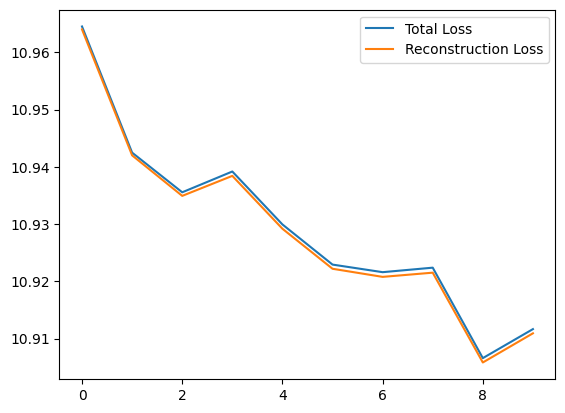

In [58]:
plt.plot(history.history["loss"], label="Total Loss")
plt.plot(history.history["reconstruction_loss"], label="Reconstruction Loss")
plt.legend()
plt.show()

In [18]:
my_n = 30 #for a n*n 2D manifold of images
figsize = 15
def plot_latent_space(vae, n, fig_size):
    digit_s = 64
    scale = 1.0
    figure = np.zeros((digit_s * n, digit_s *n,))

    x_grid = np.linspace(-scale, scale, n)
    y_grid = np.linspace(-scale, scale, n)[::-1]

    for i, yi in enumerate(y_grid):
        for j, xj in enumerate(x_grid):
            z_sample = np.array([xj, yi])
            x_decoded = vae.decoder.predict(z_sample, verbose = 0)
            digit = x_decoded[0].reshape(digit_s, digit_s)
            figure[
                i * digit_s : (i+1)*digit_s, j * digit_s : (j+1) * digit_s
            ] = digit

    plt.figure(figsize=(fig_size, fig_size))
    start_range = digit_s //2
    end_range = n* digit_s + start_range
    pixel_range = np.arange(start_range, end_range, digit_s)
    x_sample = np.round(x_grid, 1)
    y_sample = np.round(y_grid, 1)
    plt.xticks(pixel_range, x_sample)
    plt.yticks(pixel_range, y_sample)
    plt.xlabel('z[0]')
    plt.ylabel('[z[1]]')
    plt.imshow(figure, cmap='gray')
    plt.show()





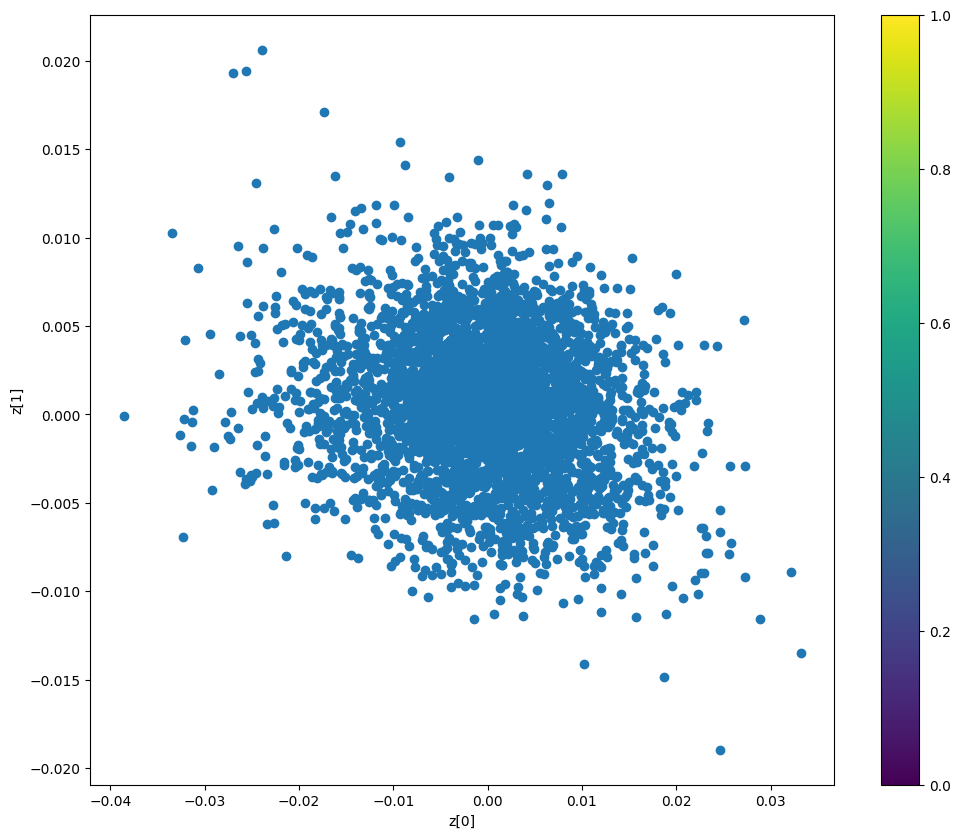

In [57]:
def plot_label_clusters(vae, data, labels):
    # display a 2D plot of the digit classes in the latent space
    z_mean, _, _ = vae.encoder.predict(data, verbose=0)
    plt.figure(figsize=(12, 10))
    plt.scatter(z_mean[:, 0], z_mean[:, 1])
    plt.colorbar()
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.show()


plot_label_clusters(vae, X_train, y_train)
